In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Upload and read Input data
data = pd.read_csv("Creditcard_data.csv")

In [3]:
# Check data
data["Class"].value_counts()

,count
Class,
0,763
1,9


In [4]:
# Balance Data
data_major = data[data.Class == 0]
data_minor = data[data.Class == 1]

data_minor_up = data_minor.sample(
    n=len(data_major),
    replace=True,
    random_state=42
)

balanced_data = pd.concat([data_major, data_minor_up])

balanced_data["Class"].value_counts()

,count
Class,
0,763
1,763


In [5]:
# Simple Random Sampling
sample_srs = balanced_data.sample(frac=0.2, random_state=1)

In [9]:
# Systematic Sampling
step = 15
sample_systematic = balanced_data.iloc[::step]

In [8]:
# Bootstrap Sampling
sample_bootstrap = balanced_data.sample(
    n=len(balanced_data),
    replace=True,
    random_state=3
)

In [6]:
# Stratified Sampling
class0 = balanced_data[balanced_data.Class == 0].sample(frac=0.25, random_state=2)
class1 = balanced_data[balanced_data.Class == 1].sample(frac=0.25, random_state=2)

sample_strat = pd.concat([class0, class1])

In [7]:
# Cluster Sampling
time_values = balanced_data["Time"].unique()
selected_time = time_values[:8]

sample_cluster = balanced_data[balanced_data["Time"].isin(selected_time)]

In [13]:
# 5 ML Models
models = [
    LogisticRegression(max_iter=1000),
    DecisionTreeClassifier(),
    RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    SVC(),
    KNeighborsClassifier()
]

model_names = ["LogReg", "DecisionTree", "RandomForest", "SVM", "KNN"]

In [11]:
# Train Models and Find Accuracy for each
def calculate_accuracy(sample):
    X = sample.drop("Class", axis=1)
    y = sample["Class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    acc_list = []

    for model in models:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        acc_list.append(round(acc * 100, 2))

    return acc_list

In [14]:
# Accuracy Table
results = pd.DataFrame(
    [
        calculate_accuracy(sample_srs),
        calculate_accuracy(sample_strat),
        calculate_accuracy(sample_cluster),
        calculate_accuracy(sample_bootstrap),
        calculate_accuracy(sample_systematic)
    ],
    columns=model_names,
    index=[
        "SimpleRandom",
        "Stratified",
        "Cluster",
        "Bootstrap",
        "Systematic"
    ]
)

results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,LogReg,DecisionTree,RandomForest,SVM,KNN
SimpleRandom,90.16,98.36,100.00,70.49,95.08
Stratified,88.31,97.40,97.40,72.73,89.61
Cluster,95.65,100.00,100.00,91.30,95.65
Bootstrap,91.50,100.00,99.67,67.32,97.71
Systematic,80.95,90.48,85.71,66.67,80.95


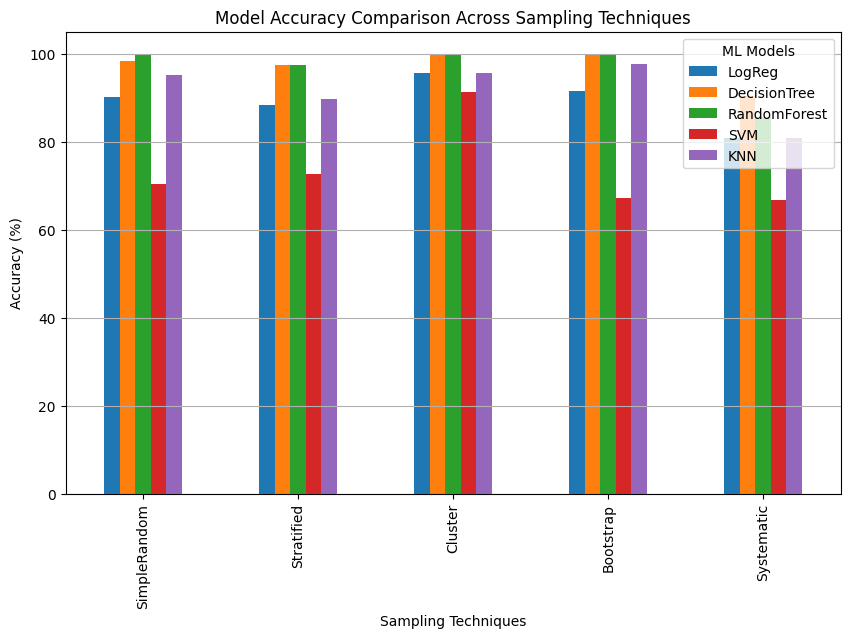

In [15]:
results.plot(kind="bar", figsize=(10,6))
plt.ylabel("Accuracy (%)")
plt.xlabel("Sampling Techniques")
plt.title("Model Accuracy Comparison Across Sampling Techniques")
plt.legend(title="ML Models")
plt.grid(axis="y")
plt.show()

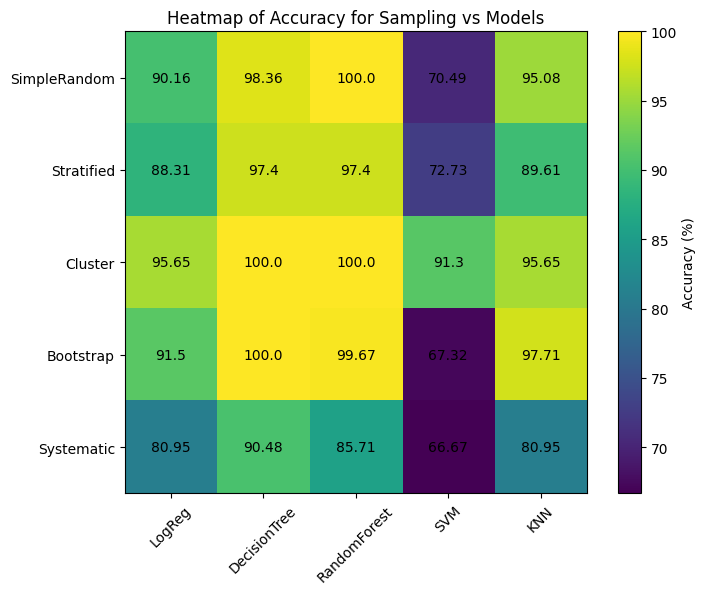

In [16]:
plt.figure(figsize=(8,6))
plt.imshow(results.values)

plt.xticks(range(len(results.columns)), results.columns, rotation=45)
plt.yticks(range(len(results.index)), results.index)

plt.colorbar(label="Accuracy (%)")
plt.title("Heatmap of Accuracy for Sampling vs Models")

for i in range(len(results.index)):
    for j in range(len(results.columns)):
        plt.text(j, i, results.values[i][j],
                 ha="center", va="center")

plt.show()
